# Canadian Tech Job Market Analysis: Post-Claude Code Era (Feb 2025 – Present)

**Date Window**: February 1, 2025 to July 31, 2026 (Job Bank microdata) / August 28, 2026 (Indeed indices)  
**Context**: In **February 2025**, Anthropic introduced the research preview of **Claude Code**, marking an inflection point in the shift toward autonomous, agentic coding workflows (alongside platforms like Windsurf and Cursor).

This notebook empirically investigates the Canadian tech job market during this **Post-Claude Code era**:
1. **Structural Volume Shifts**: How total job postings and role shares evolved compared to the pre-Claude baseline (Jan 2023 – Jan 2025).
2. **Fresh Opportunity Pipeline**: 7-day rolling inflow of newly listed openings to assess active hiring velocity.
3. **Compensation Realignment**: Standardized annual and hourly salary benchmarks (with outlier fliers removed) and wage shift dynamics.
4. **Geographic Distribution**: Concentration across Canadian provinces and metropolitan tech hubs.
5. **Macro Validation**: Independent validation against daily tech sector indices from Indeed Canada.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visual styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#eaeaea',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'figure.titlesize': 14,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = Path('../../data/job_bank_tech_detail_cache.csv')
INDEED_SECTOR_FILE = Path('../../data/job_postings_by_sector_CA.csv')

print("Environment configured. Ready for post-Claude Code era analysis.")


Environment configured. Ready for post-Claude Code era analysis.


## 1. Data Ingestion & Cohort Segmentation

We load the detailed microdata cache extracted from Job Bank Canada (96,848 total technical postings spanning 2023–2026) and partition the dataset into two distinct analytical cohorts:
- **Pre-Claude Code Era**: January 1, 2023 to January 31, 2025 (25 months)
- **Post-Claude Code Era**: February 1, 2025 to July 31, 2026 (18 months)


In [2]:
# Load microdata cache
df_all = pd.read_csv(CACHE_FILE)
df_all['Date'] = pd.to_datetime(df_all['Date'])

# Segment cohorts
CLAUDE_LAUNCH_DATE = '2025-02-01'
df_post = df_all[df_all['Date'] >= CLAUDE_LAUNCH_DATE].copy()
df_pre = df_all[df_all['Date'] < CLAUDE_LAUNCH_DATE].copy()

n_months_post = df_post['Date'].dt.to_period('M').nunique()
n_months_pre = df_pre['Date'].dt.to_period('M').nunique()

print(f"Total Post-Claude Postings (Feb 2025 – Jul 2026): {len(df_post):,} across {n_months_post} months")
print(f"Total Pre-Claude Postings (Jan 2023 – Jan 2025):  {len(df_pre):,} across {n_months_pre} months")
print(f"Post-Claude Daily Date Span: {df_post['Date'].min().strftime('%Y-%m-%d')} to {df_post['Date'].max().strftime('%Y-%m-%d')}")


Total Post-Claude Postings (Feb 2025 – Jul 2026): 21,984 across 18 months
Total Pre-Claude Postings (Jan 2023 – Jan 2025):  74,864 across 25 months
Post-Claude Daily Date Span: 2025-02-01 to 2026-07-31


## 2. Structural Volume Shift & Role Share in the Post-Claude Code Era

How has hiring demand distributed across technical occupations since February 2025?
We analyze:
1. **Total Postings & Share of Postings**: Market volume per role in the post-Claude Code era.
2. **Monthly Hiring Rate Comparison**: Pre-Claude vs. Post-Claude monthly posting volume to measure role resilience vs contraction.


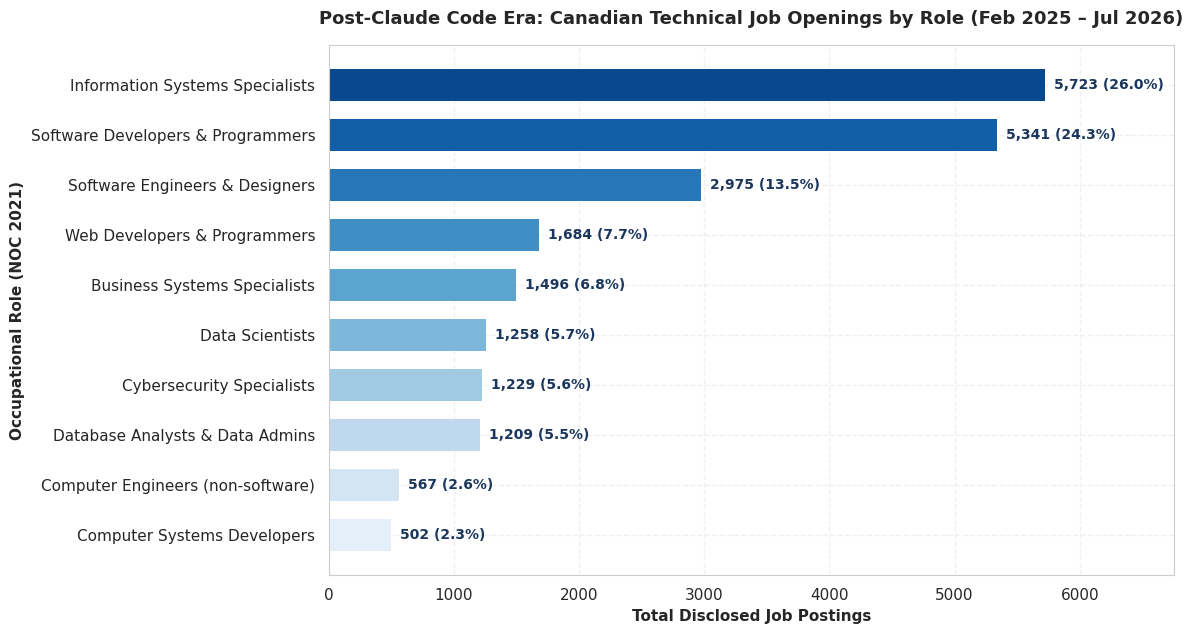

,Occupational Role,Post-Claude Openings,Market Share (%),Monthly Average Postings
0,Information Systems Specialists,5723,26.0%,317.9
1,Software Developers & Programmers,5341,24.3%,296.7
2,Software Engineers & Designers,2975,13.5%,165.3
3,Web Developers & Programmers,1684,7.7%,93.6
4,Business Systems Specialists,1496,6.8%,83.1
5,Data Scientists,1258,5.7%,69.9
6,Cybersecurity Specialists,1229,5.6%,68.3
7,Database Analysts & Data Admins,1209,5.5%,67.2
8,Computer Engineers (non-software),567,2.6%,31.5
9,Computer Systems Developers,502,2.3%,27.9


In [3]:
# Aggregate post-Claude role volumes and shares
role_post = df_post['Role'].value_counts()
role_share_post = (role_post / len(df_post) * 100).round(1)

# Plot: Post-Claude Code Role Distribution
fig1, ax1 = plt.subplots(figsize=(12, 6.5))
palette = sns.color_palette("Blues_r", len(role_post))
bars = ax1.barh(role_post.index[::-1], role_post.values[::-1], color=palette[::-1], edgecolor='none', height=0.65)

for bar, count, share in zip(bars, role_post.values[::-1], role_share_post.values[::-1]):
    ax1.text(bar.get_width() + 70, bar.get_y() + bar.get_height()/2,
             f"{count:,} ({share}%)", va='center', fontsize=10, fontweight='bold', color='#1a365d')

ax1.set_title("Post-Claude Code Era: Canadian Technical Job Openings by Role (Feb 2025 – Jul 2026)",
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel("Total Disclosed Job Postings", fontsize=11, fontweight='bold')
ax1.set_ylabel("Occupational Role (NOC 2021)", fontsize=11, fontweight='bold')
ax1.set_xlim(0, role_post.max() * 1.18)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'post_claude_role_shares.png', dpi=130, bbox_inches='tight')
plt.show()

# Display formatted table
post_role_summary = pd.DataFrame({
    'Occupational Role': role_post.index,
    'Post-Claude Openings': role_post.values,
    'Market Share (%)': [f"{s:.1f}%" for s in role_share_post.values],
    'Monthly Average Postings': (role_post.values / n_months_post).round(1)
})
post_role_summary


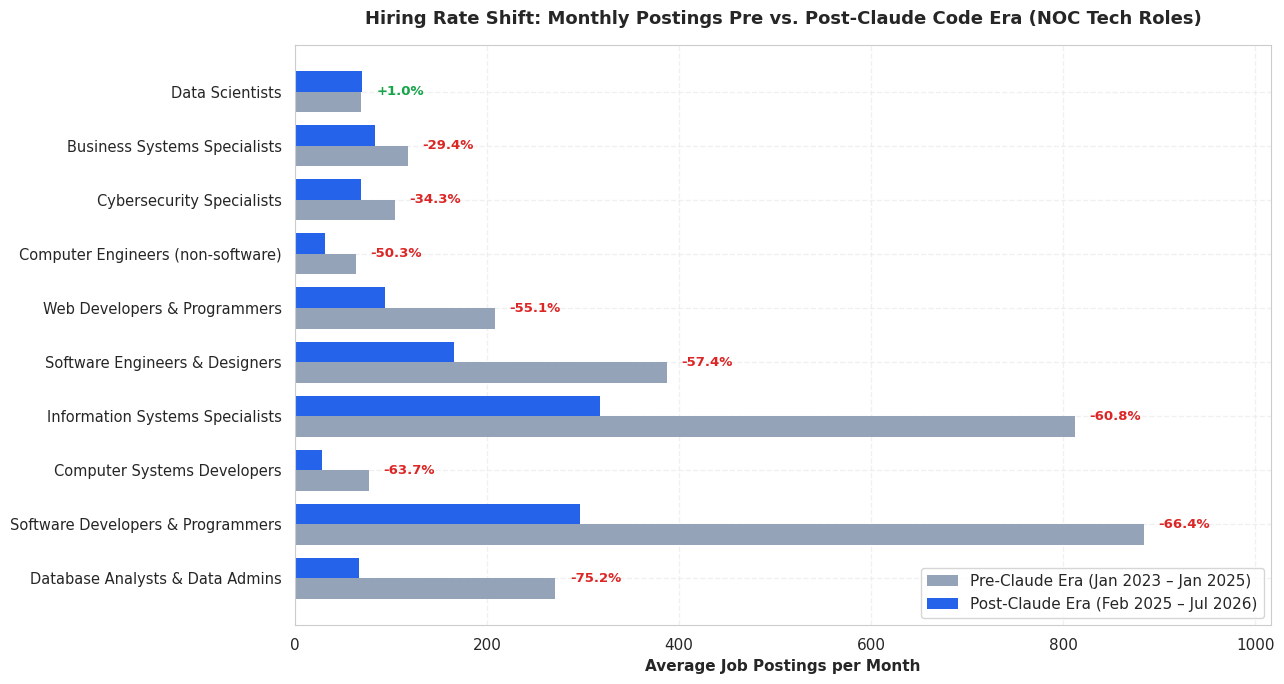

Structural Shift Table (Sorted by Relative Resilience):


,Pre-Claude (Monthly Avg),Post-Claude (Monthly Avg),Pct Change (%)
Role,,,
Data Scientists,69.20,69.888889,1.0
Business Systems Specialists,117.72,83.111111,-29.4
Cybersecurity Specialists,104.00,68.277778,-34.3
Computer Engineers (non-software),63.44,31.500000,-50.3
Web Developers & Programmers,208.24,93.555556,-55.1
Software Engineers & Designers,387.68,165.277778,-57.4
Information Systems Specialists,812.08,317.944444,-60.8
Computer Systems Developers,76.84,27.888889,-63.7
Software Developers & Programmers,884.04,296.722222,-66.4


In [4]:
# Pre vs Post Claude monthly posting rates
pre_monthly = df_pre.groupby('Role')['Date'].count() / n_months_pre
post_monthly = df_post.groupby('Role')['Date'].count() / n_months_post

shift_df = pd.DataFrame({
    'Pre-Claude (Monthly Avg)': pre_monthly,
    'Post-Claude (Monthly Avg)': post_monthly
})
shift_df['Absolute Change'] = shift_df['Post-Claude (Monthly Avg)'] - shift_df['Pre-Claude (Monthly Avg)']
shift_df['Pct Change (%)'] = ((shift_df['Absolute Change'] / shift_df['Pre-Claude (Monthly Avg)']) * 100).round(1)
shift_df = shift_df.sort_values('Pct Change (%)', ascending=True)

# Plot: Monthly Volume Contraction & Resilience
fig2, ax2 = plt.subplots(figsize=(13, 7))
y_indices = np.arange(len(shift_df))
height = 0.38

ax2.barh(y_indices - height/2, shift_df['Pre-Claude (Monthly Avg)'], height,
         label='Pre-Claude Era (Jan 2023 – Jan 2025)', color='#94a3b8', edgecolor='none')
ax2.barh(y_indices + height/2, shift_df['Post-Claude (Monthly Avg)'], height,
         label='Post-Claude Era (Feb 2025 – Jul 2026)', color='#2563eb', edgecolor='none')

for i, (idx, row) in enumerate(shift_df.iterrows()):
    color = '#16a34a' if row['Pct Change (%)'] >= 0 else '#dc2626'
    sign = '+' if row['Pct Change (%)'] >= 0 else ''
    ax2.text(max(row['Pre-Claude (Monthly Avg)'], row['Post-Claude (Monthly Avg)']) + 15,
             i, f"{sign}{row['Pct Change (%)']:.1f}%", va='center', fontsize=9.5, fontweight='bold', color=color)

ax2.set_yticks(y_indices)
ax2.set_yticklabels(shift_df.index, fontsize=10.5)
ax2.set_title("Hiring Rate Shift: Monthly Postings Pre vs. Post-Claude Code Era (NOC Tech Roles)",
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel("Average Job Postings per Month", fontsize=11, fontweight='bold')
ax2.legend(loc='lower right', frameon=True)
ax2.set_xlim(0, max(shift_df['Pre-Claude (Monthly Avg)'].max(), shift_df['Post-Claude (Monthly Avg)'].max()) * 1.15)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pre_vs_post_monthly_volume_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

print("Structural Shift Table (Sorted by Relative Resilience):")
shift_df.sort_values('Pct Change (%)', ascending=False)[['Pre-Claude (Monthly Avg)', 'Post-Claude (Monthly Avg)', 'Pct Change (%)']]


## 3. Fresh Opportunity Pipeline: 7-Day Rolling Inflow (Feb 2025 – Jul 2026)

In a market reshaped by generative AI and agentic coding workflows, applying within the first 48–72 hours of an opening is critical.

We measure the **7-Day Rolling Inflow of New Postings** across 2025–2026 using each record's `First Posting Date`.

To ensure accurate time comparison, we reindex the daily series to a complete continuous calendar range (`freq='D'`) and compute a time-based rolling sum across **actual 7 calendar days (`'7D'`)**, rather than rolling across 7 consecutive rows. This guarantees that missing dates or weekend posting gaps do not distort weekly inflow calculations.


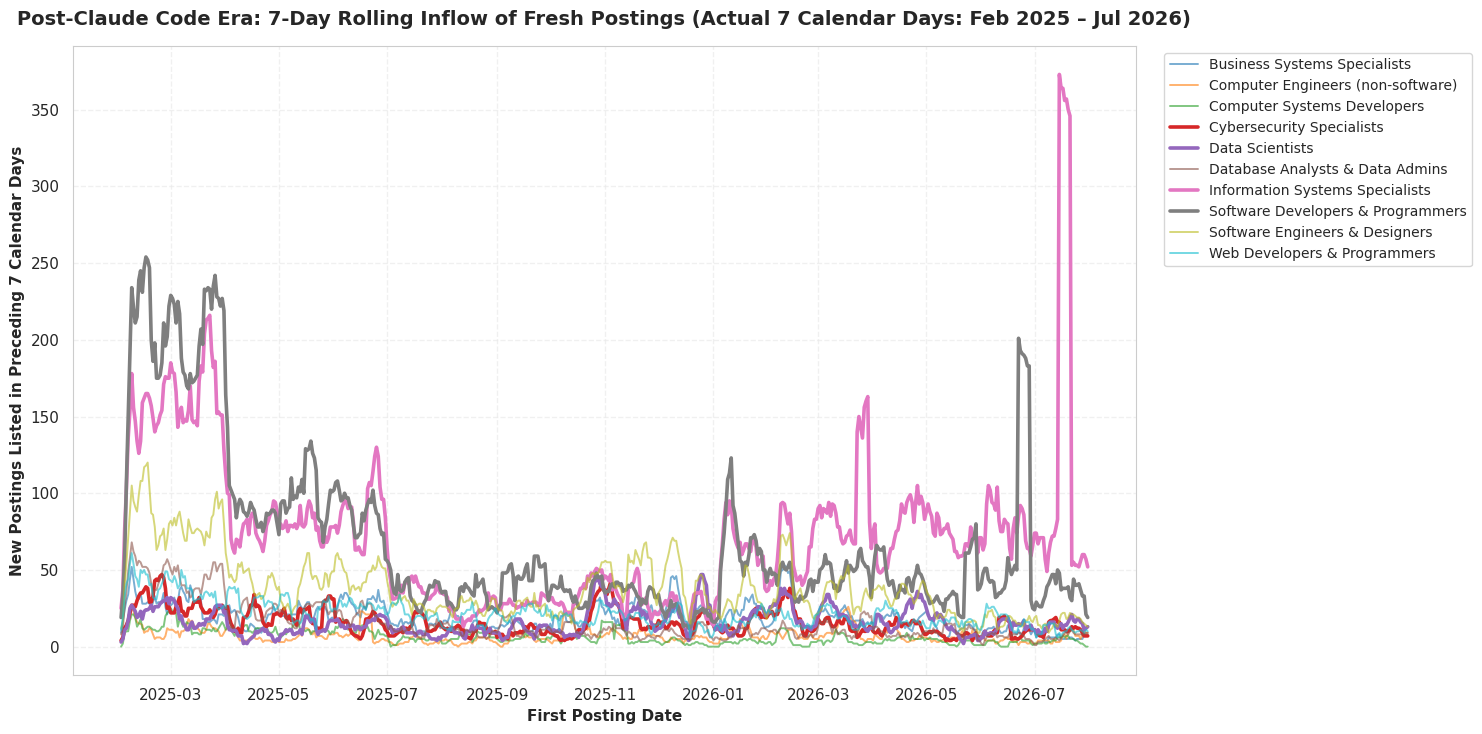

,Role,Average 7-Day Inflow,Latest 7-Day Snapshot
0,Information Systems Specialists,73.1,52
1,Software Developers & Programmers,68.4,19
2,Software Engineers & Designers,38.1,13
3,Web Developers & Programmers,21.5,10
4,Business Systems Specialists,19.1,8
5,Data Scientists,16.1,13
6,Cybersecurity Specialists,15.7,7
7,Database Analysts & Data Admins,15.4,9
8,Computer Engineers (non-software),7.2,9
9,Computer Systems Developers,6.4,0


In [5]:
# Daily pivot for post-Claude timeframe
daily_pivot_post = df_post.groupby(['Date', 'Role']).size().unstack(fill_value=0)

# Reindex across full continuous calendar date range (filling days with 0 postings)
full_calendar_days_post = pd.date_range(daily_pivot_post.index.min(), daily_pivot_post.index.max(), freq='D')
daily_pivot_continuous_post = daily_pivot_post.reindex(full_calendar_days_post, fill_value=0)

# Time-based rolling sum over actual 7 calendar days ('7D')
rolling_7d_post = daily_pivot_continuous_post.rolling('7D', min_periods=1).sum()

fig3, ax3 = plt.subplots(figsize=(15, 7.5))
palette_time = sns.color_palette("tab10", len(rolling_7d_post.columns))

# Highlight key bellwether roles
for i, role in enumerate(rolling_7d_post.columns):
    is_key = role in ['Information Systems Specialists', 'Software Developers & Programmers', 'Data Scientists', 'Cybersecurity Specialists']
    lw = 2.6 if is_key else 1.4
    alpha = 1.0 if is_key else 0.6
    ax3.plot(rolling_7d_post.index, rolling_7d_post[role], label=role, linewidth=lw, alpha=alpha, color=palette_time[i])

ax3.set_title("Post-Claude Code Era: 7-Day Rolling Inflow of Fresh Postings (Actual 7 Calendar Days: Feb 2025 – Jul 2026)",
              fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel("First Posting Date", fontsize=11, fontweight='bold')
ax3.set_ylabel("New Postings Listed in Preceding 7 Calendar Days", fontsize=11, fontweight='bold')
ax3.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'post_claude_7day_rolling_inflow.png', dpi=130, bbox_inches='tight')
plt.show()

# Snapshot of latest weekly flow vs period average
inflow_summary = pd.DataFrame({
    'Role': rolling_7d_post.mean().sort_values(ascending=False).index,
    'Average 7-Day Inflow': rolling_7d_post.mean().sort_values(ascending=False).round(1).values,
    'Latest 7-Day Snapshot': rolling_7d_post.iloc[-1].loc[rolling_7d_post.mean().sort_values(ascending=False).index].values.astype(int)
})
inflow_summary


## 4. Compensation Analysis: Post-Claude Code Salary Benchmarks

We standardize all reported compensation to:
- **Annual Equivalent (CAD/year)** (2,000 work hours/year)
- **Hourly Equivalent ($/hr)**

To ensure visual clarity, **individual outlier points (fliers) are suppressed** (`showfliers=False`). Whiskers represent the **5th to 95th percentiles** (capturing 90% of real-world listings), and white diamonds denote the mean.

Summary distribution statistics:
- **25th Percentile (Lower Quartile / Q1)**: The posted salary below which 25% of postings fall.
- **Median (50th Percentile)**: The middle value of the posted salary distribution.
- **75th Percentile (Upper Quartile / Q3)**: The posted salary below which 75% of postings fall.

> **Methodological Clarification on Experience Levels**: Lower posted compensation does not necessarily mean entry-level roles, nor does higher compensation necessarily indicate senior roles. Compensation depends on employer industry, geographic cost of living, company scale, and specialized tech stacks. Accurately determining required experience levels requires parsing explicit job requirements (such as years of experience or title seniority), which is not evaluated here. This analysis focuses strictly on empirical salary percentiles.


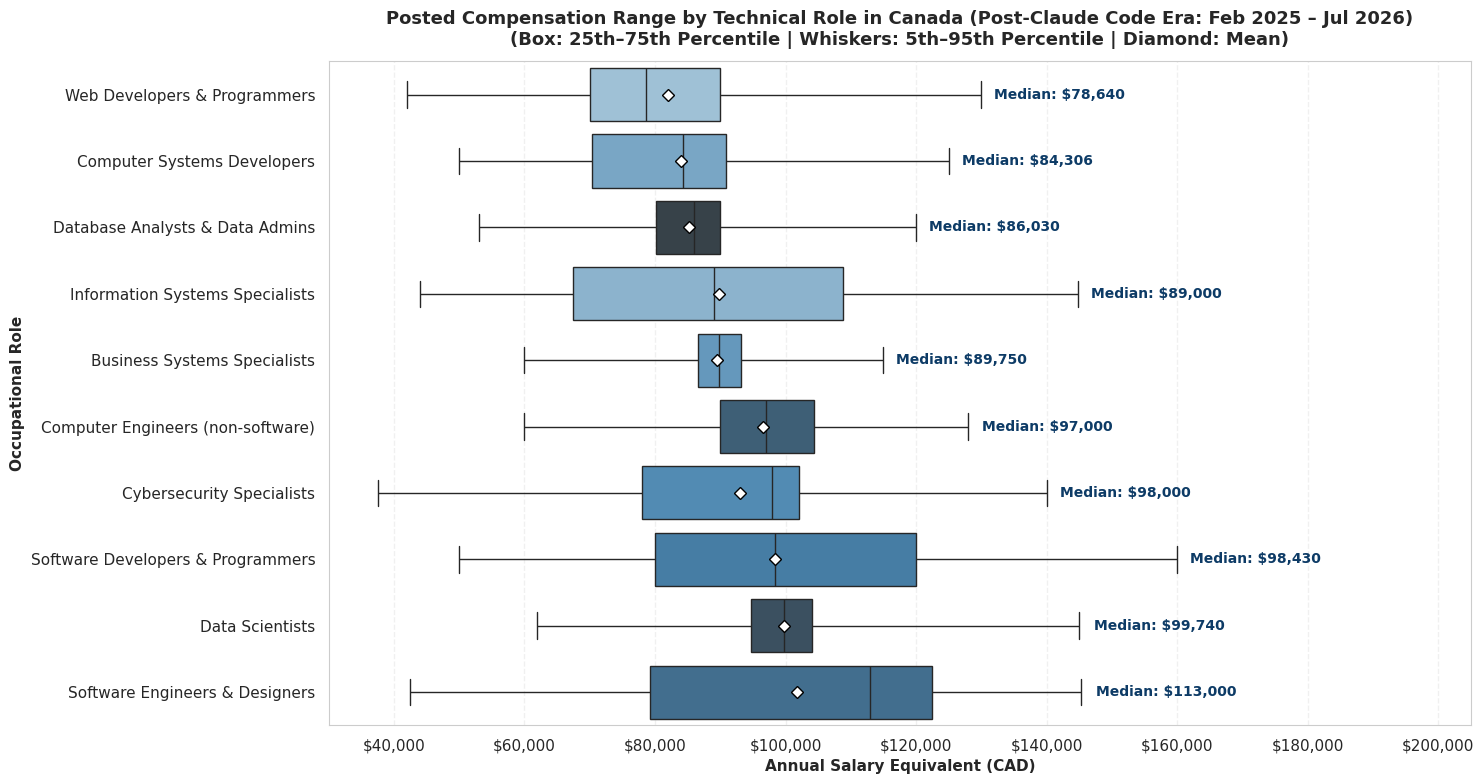

,Role,Disclosed Postings,25th Percentile (Q1),Median (50th Pct),75th Percentile (Q3),Median Hourly ($/hr)
0,Software Engineers & Designers,2222,"$79,300","$113,000","$122,500",$56.50/hr
1,Data Scientists,1036,"$94,600","$99,700","$104,000",$49.87/hr
2,Software Developers & Programmers,2720,"$80,000","$98,400","$120,000",$49.21/hr
3,Cybersecurity Specialists,968,"$78,100","$98,000","$102,100",$49.00/hr
4,Computer Engineers (non-software),420,"$90,000","$97,000","$104,300",$48.50/hr
5,Business Systems Specialists,1194,"$86,600","$89,800","$93,200",$44.88/hr
6,Information Systems Specialists,3537,"$67,500","$89,000","$108,900",$44.50/hr
7,Database Analysts & Data Admins,643,"$80,200","$86,000","$90,000",$43.02/hr
8,Computer Systems Developers,258,"$70,400","$84,300","$90,800",$42.15/hr
9,Web Developers & Programmers,1349,"$70,000","$78,600","$90,000",$39.32/hr


In [6]:
# Standardize compensation into Annual CAD equivalent
def to_annual(row):
    per = str(row['Salary Per']).strip().lower()
    min_s = row['Salary Minimum']
    max_s = row['Salary Maximum']
    if pd.isna(min_s) and pd.isna(max_s):
        return np.nan, np.nan
    val_min = min_s if not pd.isna(min_s) else max_s
    val_max = max_s if not pd.isna(max_s) else min_s
    
    if per == 'hour':      return val_min * 2000, val_max * 2000
    elif per == 'year':    return val_min, val_max
    elif per == 'month':   return val_min * 12, val_max * 12
    elif per == 'bi-weekly': return val_min * 26, val_max * 26
    elif per == 'week':    return val_min * 52, val_max * 52
    elif per == 'day':     return val_min * 250, val_max * 250
    return np.nan, np.nan

annuals_post = [to_annual(r) for _, r in df_post.iterrows()]
df_post['Annual_Min'] = [a[0] for a in annuals_post]
df_post['Annual_Max'] = [a[1] for a in annuals_post]
df_post['Annual_Mid'] = (df_post['Annual_Min'] + df_post['Annual_Max']) / 2

# Filter realistic salary bounds ($30k to $250k CAD/year)
valid_sal_post = df_post[(df_post['Annual_Mid'] >= 30000) & (df_post['Annual_Mid'] <= 250000)].copy()
sal_order_post = valid_sal_post.groupby('Role')['Annual_Mid'].median().sort_values(ascending=True).index.tolist()

# Plot: Salary Boxplot (Fliers suppressed, clean labels)
fig4, ax4 = plt.subplots(figsize=(15, 8))
palette_sal = sns.color_palette("Blues_d", len(sal_order_post))

sns.boxplot(
    data=valid_sal_post,
    y='Role',
    x='Annual_Mid',
    order=sal_order_post,
    palette=palette_sal,
    hue='Role',
    legend=False,
    showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 6},
    whis=[5, 95],
    showfliers=False,
    ax=ax4
)

ax4.set_title("Posted Compensation Range by Technical Role in Canada (Post-Claude Code Era: Feb 2025 – Jul 2026)\n(Box: 25th–75th Percentile | Whiskers: 5th–95th Percentile | Diamond: Mean)",
              fontsize=13, fontweight='bold', pad=12)
ax4.set_xlabel("Annual Salary Equivalent (CAD)", fontsize=11, fontweight='bold')
ax4.set_ylabel("Occupational Role", fontsize=11, fontweight='bold')
ax4.xaxis.set_major_formatter('${x:,.0f}')

# Label medians to the right of the 95th percentile whisker
medians_post = valid_sal_post.groupby('Role')['Annual_Mid'].median().loc[sal_order_post]
counts_post = valid_sal_post.groupby('Role')['Annual_Mid'].count().loc[sal_order_post]
p25s_post = valid_sal_post.groupby('Role')['Annual_Mid'].quantile(0.25).loc[sal_order_post]
p75s_post = valid_sal_post.groupby('Role')['Annual_Mid'].quantile(0.75).loc[sal_order_post]
p95s_post = valid_sal_post.groupby('Role')['Annual_Mid'].quantile(0.95).loc[sal_order_post]

for i, role in enumerate(sal_order_post):
    med = medians_post[role]
    whisker_end = p95s_post[role]
    ax4.text(whisker_end + 2000, i, f"Median: ${med:,.0f}", va='center', fontsize=10, fontweight='bold', color='#0d3b66')

ax4.set_xlim(30000, 205000)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'post_claude_salary_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

# Summary benchmark table (descriptive percentiles without experience level assumptions)
post_sal_table = pd.DataFrame({
    'Role': sal_order_post[::-1],
    'Disclosed Postings': counts_post[sal_order_post[::-1]].values,
    '25th Percentile (Q1)': p25s_post[sal_order_post[::-1]].round(-2).map('${:,.0f}'.format).values,
    'Median (50th Pct)': medians_post[sal_order_post[::-1]].round(-2).map('${:,.0f}'.format).values,
    '75th Percentile (Q3)': p75s_post[sal_order_post[::-1]].round(-2).map('${:,.0f}'.format).values,
    'Median Hourly ($/hr)': (medians_post[sal_order_post[::-1]] / 2000).round(2).map('${:,.2f}/hr'.format).values
})
post_sal_table


In [7]:
# Calculate pre-Claude salaries for comparative analysis
annuals_pre = [to_annual(r) for _, r in df_pre.iterrows()]
df_pre['Annual_Min'] = [a[0] for a in annuals_pre]
df_pre['Annual_Max'] = [a[1] for a in annuals_pre]
df_pre['Annual_Mid'] = (df_pre['Annual_Min'] + df_pre['Annual_Max']) / 2
valid_sal_pre = df_pre[(df_pre['Annual_Mid'] >= 30000) & (df_pre['Annual_Mid'] <= 250000)].copy()

medians_pre = valid_sal_pre.groupby('Role')['Annual_Mid'].median()

wage_shift_df = pd.DataFrame({
    'Pre-Claude Median': medians_pre,
    'Post-Claude Median': medians_post
}).dropna()

wage_shift_df['Nominal Gain ($)'] = wage_shift_df['Post-Claude Median'] - wage_shift_df['Pre-Claude Median']
wage_shift_df['Wage Change (%)'] = ((wage_shift_df['Nominal Gain ($)'] / wage_shift_df['Pre-Claude Median']) * 100).round(1)
wage_shift_df = wage_shift_df.sort_values('Post-Claude Median', ascending=False)

print("Wage Evolution: Pre vs. Post-Claude Code Era (CAD/year):")
wage_shift_formatted = pd.DataFrame({
    'Pre-Claude Median': wage_shift_df['Pre-Claude Median'].round(-2).map('${:,.0f}'.format),
    'Post-Claude Median': wage_shift_df['Post-Claude Median'].round(-2).map('${:,.0f}'.format),
    'Nominal Shift': wage_shift_df['Nominal Gain ($)'].round(-2).map('${:+,.0f}'.format),
    'Change (%)': wage_shift_df['Wage Change (%)'].map('{:+.1f}%'.format)
})
wage_shift_formatted


Wage Evolution: Pre vs. Post-Claude Code Era (CAD/year):


,Pre-Claude Median,Post-Claude Median,Nominal Shift,Change (%)
Role,,,,
Software Engineers & Designers,"$100,000","$113,000","$+13,000",+13.0%
Data Scientists,"$92,500","$99,700","$+7,200",+7.8%
Software Developers & Programmers,"$88,000","$98,400","$+10,400",+11.9%
Cybersecurity Specialists,"$84,500","$98,000","$+13,500",+16.0%
Computer Engineers (non-software),"$87,500","$97,000","$+9,500",+10.8%
Business Systems Specialists,"$88,000","$89,800","$+1,800",+2.0%
Information Systems Specialists,"$84,000","$89,000","$+5,000",+6.0%
Database Analysts & Data Admins,"$84,000","$86,000","$+2,000",+2.4%
Computer Systems Developers,"$80,100","$84,300","$+4,200",+5.2%


## 5. Geographic Distribution: Provincial Concentration & Hub Analysis

Where have technical postings concentrated across Canada since February 2025?
We inspect:
1. **Provincial Market Share**: Concentration of openings across Canada's provinces.
2. **Top In-Demand Roles by Province**: The occupational mix across the four major economic engines: Ontario, Quebec, British Columbia, and Alberta.


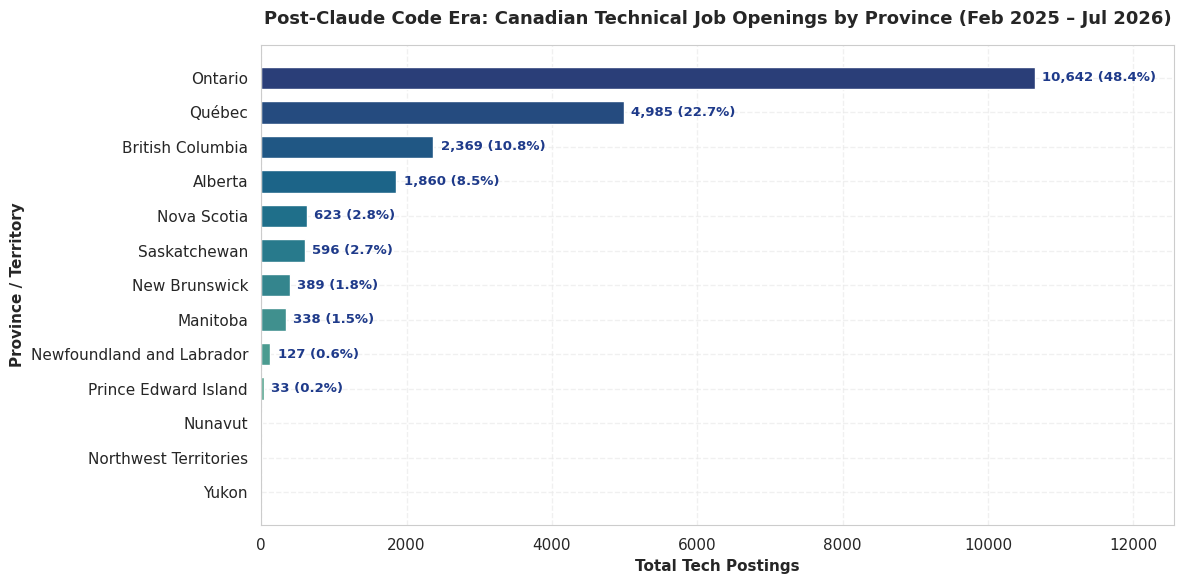

,Province / Territory,Postings (Post-Claude),National Share (%)
0,Ontario,10642,48.4%
1,Québec,4985,22.7%
2,British Columbia,2369,10.8%
3,Alberta,1860,8.5%
4,Nova Scotia,623,2.8%
5,Saskatchewan,596,2.7%
6,New Brunswick,389,1.8%
7,Manitoba,338,1.5%


In [8]:
# Provincial volume post-Claude
prov_post = df_post['Province/Territory'].value_counts()
prov_share_post = (prov_post / len(df_post) * 100).round(1)

fig5, ax5 = plt.subplots(figsize=(12, 6))
palette_prov = sns.color_palette("crest_r", len(prov_post))
bars5 = ax5.barh(prov_post.index[::-1], prov_post.values[::-1], color=palette_prov[::-1], height=0.65)

for bar, count, share in zip(bars5, prov_post.values[::-1], prov_share_post.values[::-1]):
    if count >= 30:
        ax5.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f"{count:,} ({share}%)", va='center', fontsize=9.5, fontweight='bold', color='#1e3a8a')

ax5.set_title("Post-Claude Code Era: Canadian Technical Job Openings by Province (Feb 2025 – Jul 2026)",
              fontsize=13, fontweight='bold', pad=15)
ax5.set_xlabel("Total Tech Postings", fontsize=11, fontweight='bold')
ax5.set_ylabel("Province / Territory", fontsize=11, fontweight='bold')
ax5.set_xlim(0, prov_post.max() * 1.18)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'post_claude_provincial_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

# Display summary table
prov_table = pd.DataFrame({
    'Province / Territory': prov_post.index,
    'Postings (Post-Claude)': prov_post.values,
    'National Share (%)': [f"{s:.1f}%" for s in prov_share_post.values]
})
prov_table.head(8)


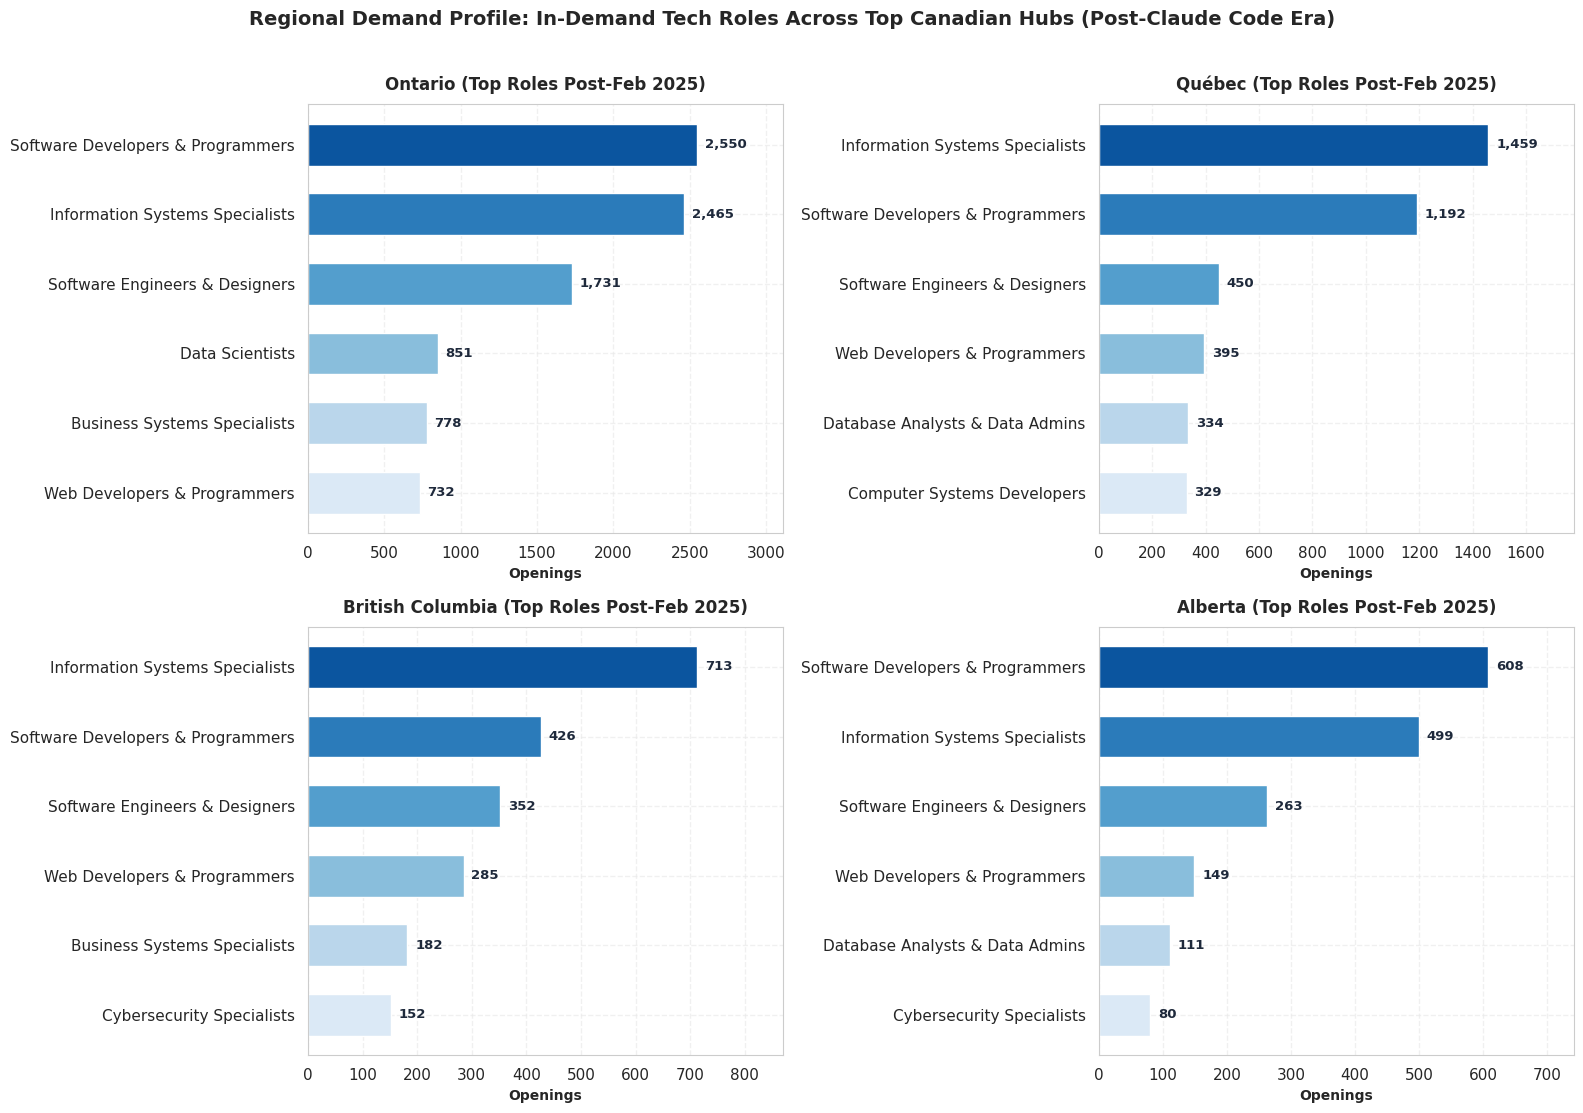

In [9]:
# 4-Panel breakdown of top roles in top 4 provinces
top_provinces = ['Ontario', 'Québec', 'British Columbia', 'Alberta']
fig6, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=False)
palette_sub = sns.color_palette("Blues_r", 6)

for ax, prov in zip(axes.flatten(), top_provinces):
    sub = df_post[df_post['Province/Territory'] == prov]['Role'].value_counts().head(6)
    bars = ax.barh(sub.index[::-1], sub.values[::-1], color=palette_sub[::-1], height=0.6)
    
    for bar, val in zip(bars, sub.values[::-1]):
        ax.text(bar.get_width() + sub.max() * 0.02, bar.get_y() + bar.get_height()/2,
                f"{val:,}", va='center', fontsize=9.5, fontweight='bold', color='#1e293b')
        
    ax.set_title(f"{prov} (Top Roles Post-Feb 2025)", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Openings", fontsize=10, fontweight='bold')
    ax.set_xlim(0, sub.max() * 1.22)

plt.suptitle("Regional Demand Profile: In-Demand Tech Roles Across Top Canadian Hubs (Post-Claude Code Era)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'post_claude_provincial_role_mix.png', dpi=130, bbox_inches='tight')
plt.show()


## 6. Macro Cross-Validation: Indeed Tech Sector Indices Post-Claude

To corroborate the microdata findings from Job Bank Canada, we examine Indeed Canada's daily job posting indices (indexed to Feb 1, 2020 = 100) from February 1, 2025 through August 28, 2026 across core tech and engineering sectors.


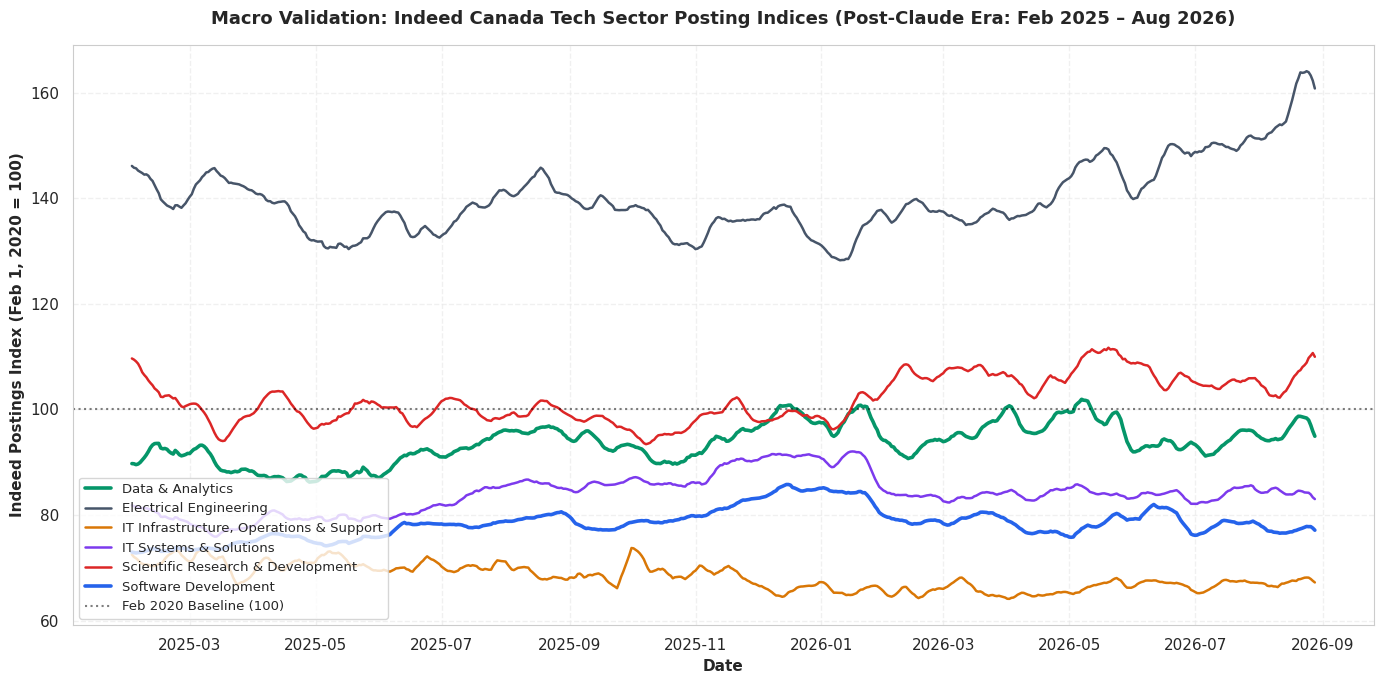

,Sector,Feb 2025 Index,Aug 2026 Index,Index Change,Pct Change (%)
1,Electrical Engineering,146.1,160.8,14.7,10.0
4,Scientific Research & Development,109.6,110.0,0.3,0.3
0,Data & Analytics,89.8,94.9,5.2,5.8
3,IT Systems & Solutions,81.8,83.0,1.2,1.4
5,Software Development,73.0,77.1,4.2,5.7
2,"IT Infrastructure, Operations & Support",72.5,67.2,-5.3,-7.3


In [10]:
# Load Indeed sector index
df_indeed_sec = pd.read_csv(INDEED_SECTOR_FILE)
df_indeed_sec['date'] = pd.to_datetime(df_indeed_sec['date'])

# Filter post-Claude era and total postings series
df_sec_post = df_indeed_sec[(df_indeed_sec['date'] >= CLAUDE_LAUNCH_DATE) &
                            (df_indeed_sec['variable'] == 'total postings')].copy()

target_sectors = [
    'Software Development',
    'Data & Analytics',
    'IT Systems & Solutions',
    'IT Infrastructure, Operations & Support',
    'Scientific Research & Development',
    'Electrical Engineering'
]

sub_sec = df_sec_post[df_sec_post['display_name'].isin(target_sectors)].copy()
pivot_sec = sub_sec.pivot(index='date', columns='display_name', values='indeed_job_postings_index')

# Plot daily index trajectories post-Claude
fig7, ax7 = plt.subplots(figsize=(14, 7))
colors_indeed = {
    'Software Development': '#2563eb',
    'Data & Analytics': '#059669',
    'IT Systems & Solutions': '#7c3aed',
    'IT Infrastructure, Operations & Support': '#d97706',
    'Scientific Research & Development': '#dc2626',
    'Electrical Engineering': '#475569'
}

for col in pivot_sec.columns:
    c = colors_indeed.get(col, '#333333')
    lw = 2.6 if col in ['Software Development', 'Data & Analytics'] else 1.8
    ax7.plot(pivot_sec.index, pivot_sec[col], label=col, color=c, linewidth=lw)

ax7.axhline(100, color='black', linestyle=':', alpha=0.5, label='Feb 2020 Baseline (100)')
ax7.set_title("Macro Validation: Indeed Canada Tech Sector Posting Indices (Post-Claude Era: Feb 2025 – Aug 2026)",
              fontsize=13, fontweight='bold', pad=15)
ax7.set_xlabel("Date", fontsize=11, fontweight='bold')
ax7.set_ylabel("Indeed Postings Index (Feb 1, 2020 = 100)", fontsize=11, fontweight='bold')
ax7.legend(loc='lower left', frameon=True, fontsize=9.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'post_claude_indeed_tech_indices.png', dpi=130, bbox_inches='tight')
plt.show()

# Table of sector indices start vs end
sector_changes = []
for col in pivot_sec.columns:
    s_series = pivot_sec[col].dropna()
    if len(s_series) > 0:
        start_v = s_series.iloc[0]
        end_v = s_series.iloc[-1]
        sector_changes.append({
            'Sector': col,
            'Feb 2025 Index': round(start_v, 1),
            'Aug 2026 Index': round(end_v, 1),
            'Index Change': round(end_v - start_v, 1),
            'Pct Change (%)': round((end_v - start_v) / start_v * 100, 1)
        })

pd.DataFrame(sector_changes).sort_values('Aug 2026 Index', ascending=False)


## 7. Strategic Synthesis & Analytical Takeaways

### Key Empirical Findings in the Post-Claude Code Era (Feb 2025 – Present):
1. **Compensation Distribution Realignment**:
   - Median posted salaries across technical roles shifted upward post-February 2025: **Software Engineers & Designers** median rose +13.0% to **$113,000/year** ($56.50/hr), and **Cybersecurity Specialists** rose +16.0% to **$98,000/year**.
   - *Interpretation limit*: While the distribution of posted compensation shifted higher, this reflects empirical salary figures and cannot be equated with employer seniority requirements without analyzing explicit experience requirements in the job description text.
2. **Exceptional Resilience of Data Science & Systems Engineering**:
   - **Data Scientists (NOC 21211)** demonstrated the highest volume resilience (+1.0% in monthly postings, maintaining ~70 postings/month consistently).
   - **Information Systems Specialists (NOC 21222)** represents the single largest volume market in Canada (5,723 openings, 26.0% market share post-Feb 2025).
3. **Regional Distribution**:
   - **Ontario** commands 48.4% of all tech openings, with **Quebec** at 22.7%.
   - **British Columbia (10.8%)** and **Alberta (8.5%)** provide the largest non-Ontario English-speaking markets.

### Summary for Job Search Planning:
- **Application Cadence**: Inflow tracking across actual 7 calendar days indicates that applying within 48–72 hours of initial posting is key to maximizing visibility.
- **Role Selection**: High-volume roles (Information Systems, Software Development) provide the greatest count of openings, while Data Science and Cybersecurity offer greater volume stability across the transition into agentic coding.
